# Naive Bayes 

Naive Bayes is a machine learning classification algorithm that predicts the category of a data point using probability. It assumes that all features are independent of each other. Naive Bayes performs well in many real-world applications such as spam filtering, document categorisation and sentiment analysis.

which is a probability theory that describes the probability of an event, based on prior knowledge of conditions that might be related to that event .

Naive : It is called Naive because it assumes that the occurence of a certain feature is independent of the occurence of other features.

Bayes :: it is called Bayes because it depends on the principle of Bayes's theorem

# Types of Naive Bayes Model

1. Gaussian NB : Assumes that continuous features follow a Gaussian distribution .
                 suitable for features that are continuous and have a normal distribution.

2. Bernoulii NB : Assumes that features are binary(Boolean) variables \ GFG.

3. Multinomial NB : Assumes that features follows a multinomial distribution .
                  typically usesd for dicrete data , such as text data ,where each feature represents the frequency of a team

In [46]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from mlxtend.plotting import plot_decision_regions # for checking distribution

In [47]:
dataset  = pd.read_csv("Placement.csv")
dataset.head()

,Student_ID,CGPA,IQ,Placement
0,1,6.8,123,1
1,2,5.9,106,0
2,3,5.3,121,0
3,4,7.4,132,1
4,5,5.8,142,0


In [48]:
dataset.isnull().sum()

Student_ID    0
CGPA          0
IQ            0
Placement     0
dtype: int64

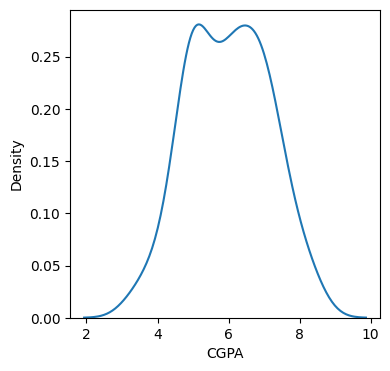

In [49]:
plt.figure(figsize=(4,4))
sns.kdeplot(data=dataset['CGPA'])  # check IQ distribution tooo
plt.show()

Check : Data is Linearly or Non Linearly seperable

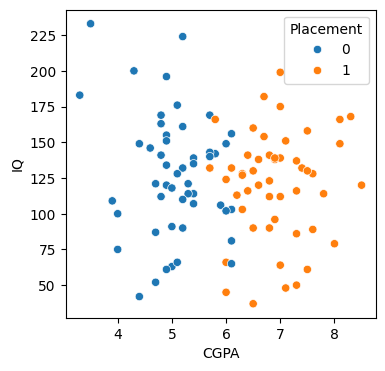

In [50]:
plt.figure(figsize=(4,4))
sns.scatterplot(x ="CGPA",y ="IQ" , data= dataset,hue="Placement")
plt.show()
# This is linearly seperable

Seperating the data : independent and dependent variables

In [51]:
x = dataset.iloc[:,[1,2]]
y = dataset["Placement"]

train test split :

In [52]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train ,y_test = train_test_split(x,y,random_state=42,train_size=0.2)

# Trying all NB : Gaussian , Multinomial , Bernoulli 

...For practice i am using all three but in actual project check the distribution of data then apply Naive Bayes according to the Distribution.

...like for Normal Distribution use Gaussian , For Binary use Bernoulli and For text or descrete use Multinomial 

In [53]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

Gaussian : For Normal Distribution

In [54]:
gnb = GaussianNB()
gnb.fit(x_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [55]:
# Accuracy analysis :

gnb.score(x_test,y_test)*100  , gnb.score(x_train,y_train)*100

(92.5, 90.0)

MultiNomial : for descrete or text distribution

In [56]:
mnb = MultinomialNB()
mnb.fit(x_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [57]:
# Accuracy analysis :

mnb.score(x_test,y_test)*100 , mnb.score(x_train,y_train)*100


(56.25, 60.0)

Bernoulli : for Binary Distribution

In [58]:
bnb = BernoulliNB()
bnb.fit(x_test,y_test)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [59]:
# Accuracy analysis :

bnb.score(x_test,y_test)*100 , bnb.score(x_train,y_train)*100

(52.5, 40.0)

Making Decision Region : 

/home/ayush-paliwal/PythonEnvironments/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


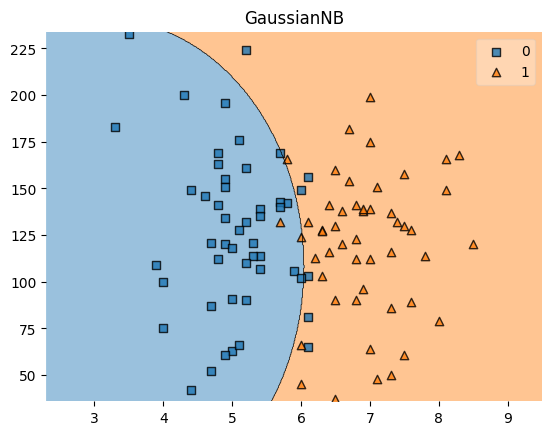

In [60]:
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=gnb)
plt.title("GaussianNB")
plt.show()

/home/ayush-paliwal/PythonEnvironments/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(


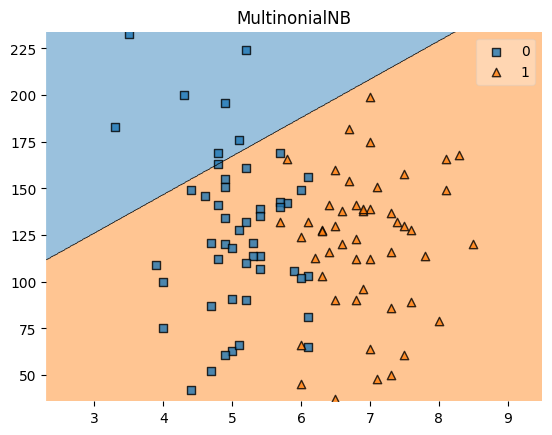

In [61]:
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=mnb)
plt.title("MultinonialNB")
plt.show()

/home/ayush-paliwal/PythonEnvironments/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but BernoulliNB was fitted with feature names
  warnings.warn(


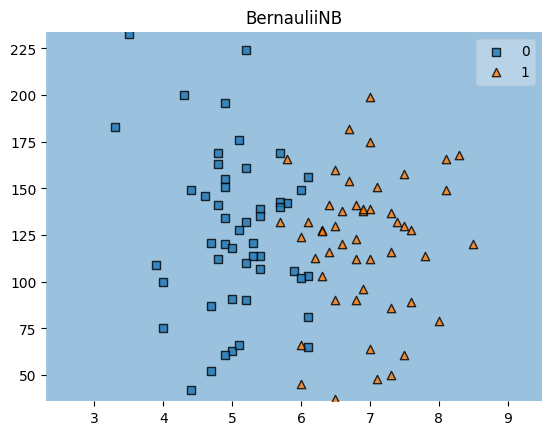

In [62]:
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=bnb)
plt.title("BernauliiNB")
plt.show()